# 03 · Modelos no supervisados (clustering)

**Proyecto Final — Machine Learning y Deep Learning**

### ¿Qué es esto y por qué?
Hasta ahora hemos hecho aprendizaje **supervisado**: el modelo aprende a predecir una respuesta conocida (`is_canceled`). En el aprendizaje **no supervisado** no hay respuesta: el algoritmo busca **estructura por sí solo**. El caso típico es el *clustering* (agrupamiento): repartir las reservas en **grupos (clusters)** de modo que las de un mismo grupo se parezcan entre sí.

### El objetivo aquí
Queremos descubrir **segmentos naturales de reservas** y, sobre todo, ver si esos segmentos **cancelan de forma muy distinta**. Si es así, confirmaríamos desde otro ángulo por qué variables como `deposit_type` o `lead_time` son tan predictivas. Seguimos las técnicas vistas en la *Clase 3* del curso (K-Means, método del codo, *silhouette*, t-SNE).

> 📖 Términos técnicos explicados en `docs/glosario.md`.

## 1. Datos y preprocesado

Reutilizamos **el mismo preprocesado** del proyecto (imputación + estandarización + *one-hot*), porque K-Means mide **distancias** y necesita que todas las variables estén en una escala comparable. Agrupamos sobre el conjunto de entrenamiento.

In [1]:
%matplotlib inline
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

from src import config
from src.data_loader import load_and_prepare
from src.preprocessing import build_preprocessor

X_train, X_test, y_train, y_test = load_and_prepare()
prep = build_preprocessor().fit(X_train)
Z = prep.transform(X_train)            # matriz numérica escalada (lo que ve K-Means)
print('Reservas a agrupar:', Z.shape[0], '| características tras el preprocesado:', Z.shape[1])

Reservas a agrupar: 95368 | características tras el preprocesado: 126


## 2. ¿Cuántos grupos (k)? Método del codo y *silhouette*

K-Means necesita que le digamos **cuántos grupos** queremos (`k`). Para orientarnos usamos dos diagnósticos:

- **Método del codo** (*elbow*): la **inertia** mide lo compactos que son los grupos (suma de distancias de cada punto a su centro). Baja siempre al añadir grupos; buscamos el "codo", donde **deja de bajar rápido**.
- **Coeficiente de *silhouette*** (de −1 a 1): mide si cada punto está bien dentro de su grupo y lejos de los demás. **Más alto = grupos mejor separados**.

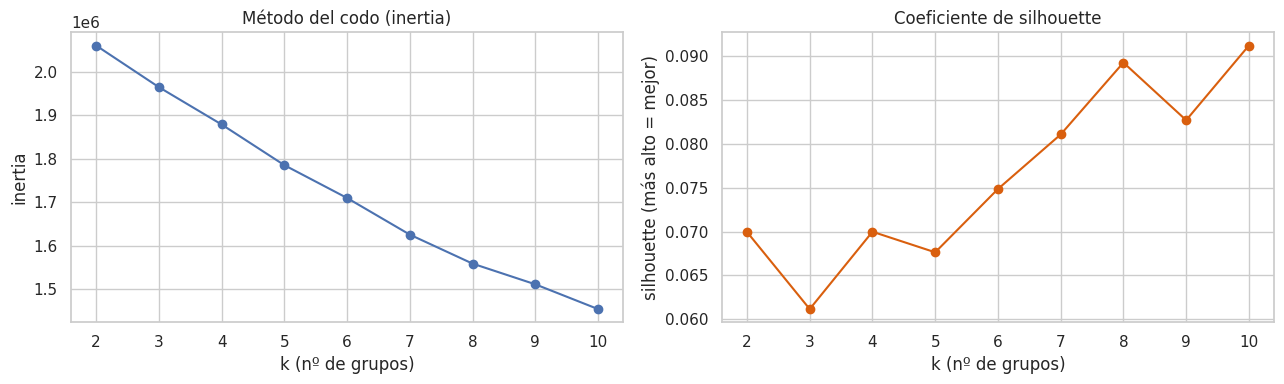

In [2]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
inertias, silhouettes = [], []
sub = np.random.RandomState(config.RANDOM_STATE).choice(len(Z), 5000, replace=False)  # silhouette es costoso
for k in ks:
    km = KMeans(n_clusters=k, n_init=5, random_state=config.RANDOM_STATE).fit(Z)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(Z[sub], km.labels_[sub]))

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
a1.plot(list(ks), inertias, 'o-'); a1.set_title('Método del codo (inertia)')
a1.set_xlabel('k (nº de grupos)'); a1.set_ylabel('inertia')
a2.plot(list(ks), silhouettes, 'o-', color='#d95f0e'); a2.set_title('Coeficiente de silhouette')
a2.set_xlabel('k (nº de grupos)'); a2.set_ylabel('silhouette (más alto = mejor)')
plt.tight_layout(); plt.show()

**Lectura.** La inertia baja de forma **suave**, sin un codo claro, y el *silhouette* es **bajo** (≈ 0.06–0.09) y sigue subiendo poco a poco. Es lo habitual con datos dominados por variables categóricas (*one-hot*): **no forman bolas bien separadas**. No hay un `k` matemáticamente "óptimo", así que lo elegimos por **interpretabilidad**: tomamos **k = 7**, que ya está cerca del máximo de *silhouette* y, como veremos, separa los segmentos extremos sin fragmentar de más.

## 3. K-Means con k = 7

In [3]:
k_elegido = 7
kmeans = KMeans(n_clusters=k_elegido, n_init=10, random_state=config.RANDOM_STATE).fit(Z)
clusters = kmeans.labels_
print('Tamaño de cada grupo:')
print(pd.Series(clusters).value_counts().sort_index())

Tamaño de cada grupo:
0     5054
1    32000
2    26697
3    22630
4      113
5     5849
6     3025
Name: count, dtype: int64


## 4. Perfil de cada segmento y su tasa de cancelación

Aquí está lo interesante: describimos cada grupo (su variable más típica) y calculamos su **tasa de cancelación**. Si los grupos cancelan de forma muy distinta, el clustering ha encontrado **segmentos de riesgo**.

In [4]:
perfil = X_train.copy()
perfil['cluster'] = clusters
perfil['is_canceled'] = y_train.values

tabla = perfil.groupby('cluster').agg(
    reservas=('is_canceled', 'size'),
    tasa_cancelacion=('is_canceled', 'mean'),
    lead_time_med=('lead_time', 'median'),
    adr_med=('adr', 'median'),
)
tabla['%_del_total'] = (tabla['reservas'] / len(perfil) * 100).round(1)
for col in ['deposit_type', 'market_segment', 'hotel', 'customer_type']:
    tabla[col] = perfil.groupby('cluster')[col].agg(lambda s: s.mode().iloc[0])
tabla = tabla.sort_values('tasa_cancelacion', ascending=False)
tabla.style.background_gradient(cmap='Reds', subset=['tasa_cancelacion']).format(
    {'tasa_cancelacion': '{:.0%}', 'lead_time_med': '{:.0f}', 'adr_med': '{:.0f}', '%_del_total': '{:.1f}'})

,reservas,tasa_cancelacion,lead_time_med,adr_med,%_del_total,deposit_type,market_segment,hotel,customer_type
cluster,,,,,,,,,
4,113,99%,244,50,0.1,Non Refund,Groups,Resort Hotel,Transient
2,26697,45%,102,80,28.0,No Deposit,Offline TA/TO,City Hotel,Transient
5,5849,41%,69,158,6.1,No Deposit,Online TA,City Hotel,Transient
1,32000,40%,55,89,33.6,No Deposit,Online TA,City Hotel,Transient
3,22630,33%,93,123,23.7,No Deposit,Online TA,City Hotel,Transient
6,3025,15%,3,65,3.2,No Deposit,Corporate,City Hotel,Transient
0,5054,0%,24,101,5.3,No Deposit,Online TA,Resort Hotel,Transient


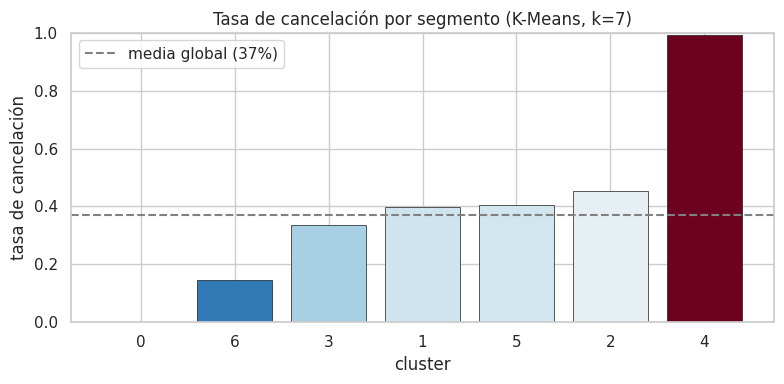

In [5]:
# Tasa de cancelación por segmento (vs. media global)
tasa = perfil.groupby('cluster')['is_canceled'].mean().sort_values()
fig, ax = plt.subplots(figsize=(8, 4))
colores = plt.cm.RdBu_r(tasa.values)
ax.bar(tasa.index.astype(str), tasa.values, color=colores, edgecolor='k', linewidth=0.5)
ax.axhline(perfil['is_canceled'].mean(), ls='--', color='gray',
           label=f"media global ({perfil['is_canceled'].mean():.0%})")
ax.set_xlabel('cluster'); ax.set_ylabel('tasa de cancelación'); ax.set_ylim(0, 1)
ax.set_title('Tasa de cancelación por segmento (K-Means, k=7)'); ax.legend()
plt.tight_layout(); plt.show()

**Hallazgos.** Los segmentos cancelan de forma **radicalmente distinta**, desde casi **0 %** hasta casi **100 %**:

- Un grupo de **Resort + Online TA + poca antelación** no cancela casi nunca (~0 %).
- Un pequeño grupo de **`deposit_type = Non Refund` + Groups** cancela **casi siempre** (~99 %) — el depósito no reembolsable suele asociarse a reservas que nunca llegan a materializarse.
- Las reservas **Corporate de última hora** cancelan poco (~15 %).

Es la **misma señal** que detectaron los modelos supervisados (`deposit_type`, `lead_time`, `market_segment`), pero ahora **emergió sola**, sin mirar la etiqueta. Eso refuerza que esas variables capturan segmentos reales de negocio.

## 5. Visualización de los segmentos (t-SNE)

Proyectamos una muestra a 2D con **t-SNE** (misma técnica del notebook 02) y la coloreamos de dos formas: por **cluster** y por **cancelación real**. Si los colores se parecen, los grupos *coinciden* con zonas de mayor/menor cancelación.

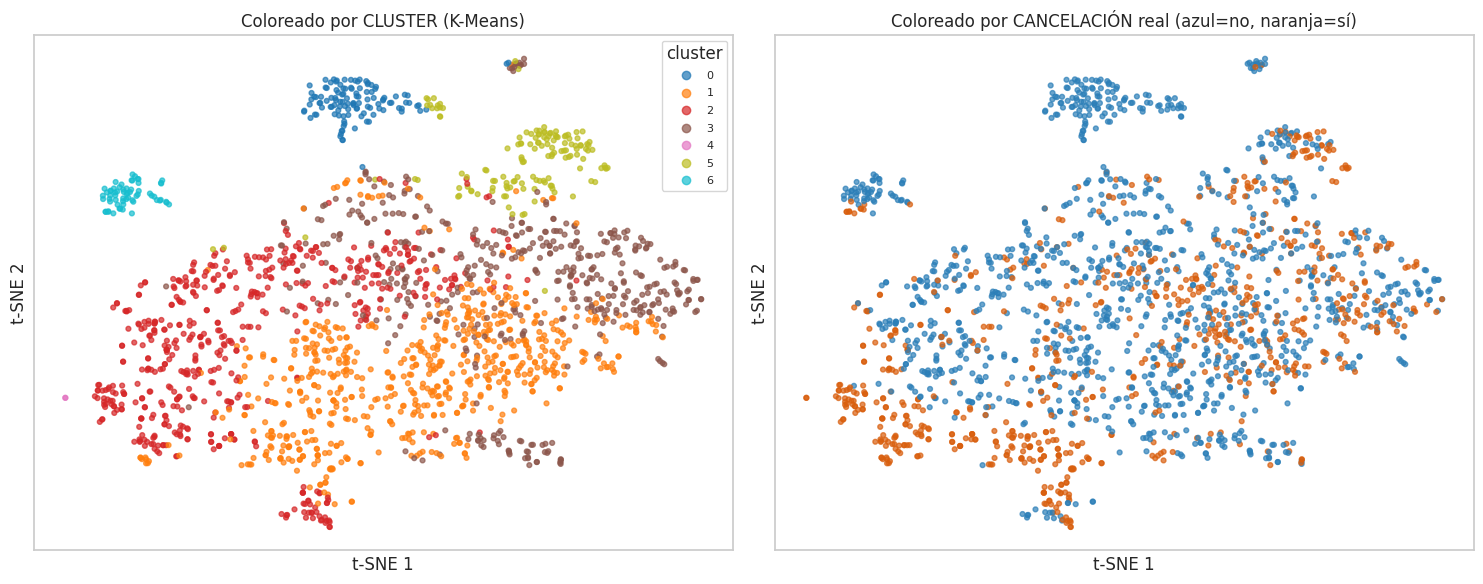

In [6]:
from sklearn.manifold import TSNE

idx = np.random.RandomState(config.RANDOM_STATE).choice(len(Z), 2000, replace=False)
coords = TSNE(n_components=2, random_state=config.RANDOM_STATE,
              perplexity=30, init='pca').fit_transform(Z[idx])

fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 6))
sc1 = a1.scatter(coords[:, 0], coords[:, 1], c=clusters[idx], cmap='tab10', s=12, alpha=0.7)
a1.set_title('Coloreado por CLUSTER (K-Means)'); a1.legend(*sc1.legend_elements(), title='cluster', fontsize=8)
a2.scatter(coords[:, 0], coords[:, 1], c=y_train.values[idx],
           cmap=plt.matplotlib.colors.ListedColormap(['#2c7fb8', '#d95f0e']), s=12, alpha=0.7)
a2.set_title('Coloreado por CANCELACIÓN real (azul=no, naranja=sí)')
for ax in (a1, a2): ax.set_xticks([]); ax.set_yticks([]); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout(); plt.show()

**Lectura.** t-SNE separa la muestra en varios "grumos", y los clusters de K-Means se corresponden bastante bien con ellos. Comparando los dos paneles se ve que **algunos grumos son mayoritariamente naranjas** (segmentos que cancelan mucho) y otros azules (que casi no cancelan): el agrupamiento no supervisado y la cancelación **no son independientes**.

## 6. Conclusión

Sin usar la etiqueta, K-Means encuentra **segmentos de reserva con comportamientos de cancelación muy distintos** (de ~0 % a ~99 %), definidos sobre todo por `deposit_type`, el tipo de hotel, el `market_segment` y `lead_time`. Esto:

1. **Confirma** desde el lado no supervisado por qué esas variables son las más predictivas en los modelos del notebook 02.
2. Tiene **valor de negocio**: permitiría tratar de forma distinta a cada segmento (p. ej., políticas de *overbooking* o de depósito según el riesgo del grupo).

Limitaciones: los grupos no están *nítidamente* separados (silhouette bajo), porque los datos son mayoritariamente categóricos; K-Means con distancia euclídea no es lo ideal para ese tipo de variables, pero resulta suficiente para una **segmentación orientativa**.